## Agricultural Output by State: Nigeria (2014-2024)

In [1]:
import pandas as pd

# Load the dataset
df_crop_output = pd.read_csv('/content/raw_crop_output_nigeria_2014_2024.csv')

# Display the first 5 rows of the DataFrame
display(df_crop_output.head())

,state,crop,year,area_harvested_ha,yield_t_per_ha,production_tonnes
0,Abia,Cassava,2014,131905.4,9.65,1272835.7
1,Abia,Cassava,2015,98707.3,12.48,1232025.1
2,Abia,Cassava,2016,99481.4,11.37,1130849.2
3,Abia,Cassava,2017,100319.2,13.37,1341549.5
4,Abia,Cassava,2018,142790.2,10.18,1454077.2


In [2]:
print('DataFrame Info:')
df_crop_output.info()

print('\nDataFrame Description:')
display(df_crop_output.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1145 entries, 0 to 1144
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   state              1145 non-null   object 
 1   crop               1145 non-null   object 
 2   year               1145 non-null   int64  
 3   area_harvested_ha  1145 non-null   float64
 4   yield_t_per_ha     1145 non-null   float64
 5   production_tonnes  1130 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 53.8+ KB

DataFrame Description:


,year,area_harvested_ha,yield_t_per_ha,production_tonnes
count,1145.000000,1.145000e+03,1145.000000,1.130000e+03
mean,2018.996507,1.715698e+05,6.981799,1.316032e+06
std,3.164486,1.516704e+05,4.939477,2.907627e+06
min,2014.000000,8.973500e+03,1.600000,4.600130e+04
25%,2016.000000,6.199960e+04,2.310000,2.299349e+05
50%,2019.000000,1.294600e+05,3.110000,5.651009e+05
75%,2022.000000,2.346733e+05,11.900000,1.925099e+06
max,2024.000000,1.103645e+06,14.990000,8.345787e+07


In [3]:
# Identify rows with missing values in 'production_tonnes'
missing_production = df_crop_output[df_crop_output['production_tonnes'].isnull()]

print('\nRows with missing production_tonnes values:')
display(missing_production)


Rows with missing production_tonnes values:


,state,crop,year,area_harvested_ha,yield_t_per_ha,production_tonnes
58,Cross River,Cassava,2017,327046.3,11.58,NaN
112,Enugu,Cassava,2016,339268.8,9.88,NaN
128,FCT Abuja,Cassava,2021,14837.1,13.00,NaN
170,Kwara,Cassava,2019,63899.0,10.64,NaN
330,Cross River,Maize,2014,25815.1,2.25,NaN
453,Kebbi,Maize,2016,180964.2,2.18,NaN
544,Plateau,Maize,2019,373523.9,2.21,NaN
648,Borno,Rice,2024,28168.4,3.02,NaN
760,Kebbi,Rice,2015,497342.8,2.09,NaN
942,Cross River,Yam,2021,148092.5,11.27,NaN


In [4]:
# Impute missing 'production_tonnes' using area_harvested_ha * yield_t_per_ha
df_crop_output['production_tonnes'] = df_crop_output['production_tonnes'].fillna(
    df_crop_output['area_harvested_ha'] * df_crop_output['yield_t_per_ha']
)

# Verify that there are no more missing values in 'production_tonnes'
print('Number of missing values in production_tonnes after imputation:', df_crop_output['production_tonnes'].isnull().sum())

# Display some of the imputed rows to confirm (e.g., re-display the head of the previously missing rows)
print('\nSample of rows where production_tonnes was imputed:')
display(df_crop_output.loc[missing_production.index].head())

Number of missing values in production_tonnes after imputation: 0

Sample of rows where production_tonnes was imputed:


,state,crop,year,area_harvested_ha,yield_t_per_ha,production_tonnes
58,Cross River,Cassava,2017,327046.3,11.58,3787196.154
112,Enugu,Cassava,2016,339268.8,9.88,3351975.744
128,FCT Abuja,Cassava,2021,14837.1,13.00,192882.300
170,Kwara,Cassava,2019,63899.0,10.64,679885.360
330,Cross River,Maize,2014,25815.1,2.25,58083.975


In [6]:
print("Unique values in 'state' column:")
print(df_crop_output['state'].unique())

print("\nUnique values in 'crop' column:")
print(df_crop_output['crop'].unique())

Unique values in 'state' column:
['Abia' 'Akwa Ibom' 'Anambra' 'Bayelsa' 'Benue' 'Cross River' 'Delta'
 'Ebonyi' 'Edo' 'Ekiti' 'Enugu' 'FCT Abuja' 'Abuja FCT' 'Imo' 'Kaduna'
 'Kogi' 'Kwara' 'Lagos' 'Nasarawa' 'Niger' 'Ogun' 'Ondo' 'Osun' 'Oyo'
 'Plateau' 'Rivers' 'Taraba' 'Adamawa' 'Bauchi' 'Borno' 'Gombe' 'Jigawa'
 'Kano' 'Katsina' 'Kebbi' 'Sokoto' 'Yobe' 'Zamfara']

Unique values in 'crop' column:
['Cassava' 'Maize' 'Rice' 'Yam']


In [7]:
# Standardize 'Abuja FCT' to 'FCT Abuja'
df_crop_output['state'] = df_crop_output['state'].replace('Abuja FCT', 'FCT Abuja')

# Verify the unique values again after cleaning
print("Unique values in 'state' column after standardization:")
print(df_crop_output['state'].unique())

Unique values in 'state' column after standardization:
['Abia' 'Akwa Ibom' 'Anambra' 'Bayelsa' 'Benue' 'Cross River' 'Delta'
 'Ebonyi' 'Edo' 'Ekiti' 'Enugu' 'FCT Abuja' 'Imo' 'Kaduna' 'Kogi' 'Kwara'
 'Lagos' 'Nasarawa' 'Niger' 'Ogun' 'Ondo' 'Osun' 'Oyo' 'Plateau' 'Rivers'
 'Taraba' 'Adamawa' 'Bauchi' 'Borno' 'Gombe' 'Jigawa' 'Kano' 'Katsina'
 'Kebbi' 'Sokoto' 'Yobe' 'Zamfara']


In [8]:
# Calculate total production per crop
total_production_per_crop = df_crop_output.groupby('crop')['production_tonnes'].sum().sort_values(ascending=False)

print('\nTotal Production (tonnes) per Crop:')
display(total_production_per_crop)


Total Production (tonnes) per Crop:


,production_tonnes
crop,
Cassava,6.507581e+08
Yam,6.506291e+08
Maize,1.239995e+08
Rice,8.313793e+07


/tmp/ipykernel_1760/1074432653.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_production_per_crop.index, y=total_production_per_crop.values, palette='viridis')


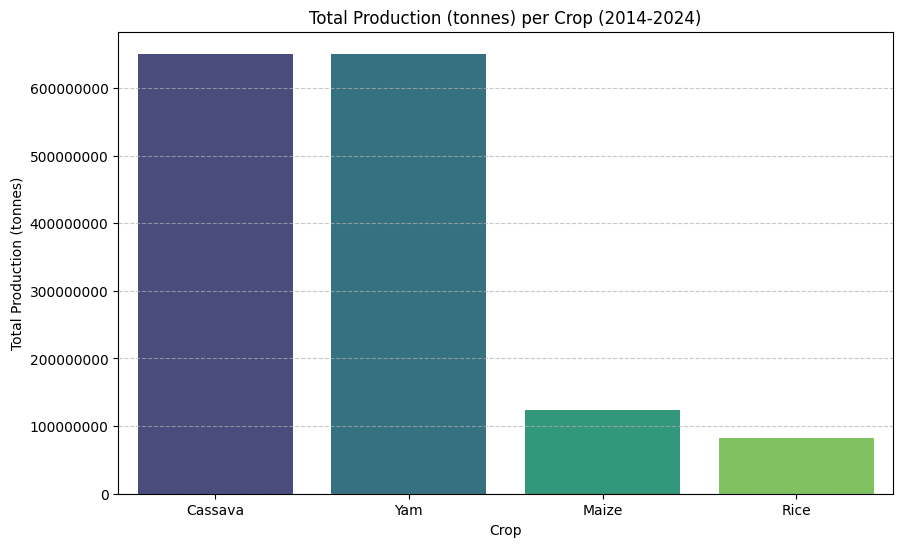

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=total_production_per_crop.index, y=total_production_per_crop.values, palette='viridis')
plt.title('Total Production (tonnes) per Crop (2014-2024)')
plt.xlabel('Crop')
plt.ylabel('Total Production (tonnes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Disable scientific notation for y-axis
plt.show()

### Production by State for Yam, Cassava, and Rice

In [10]:
# Calculate total production per state and crop
production_by_state_crop = df_crop_output.groupby(['state', 'crop'])['production_tonnes'].sum().reset_index()

# Filter for Yam, Cassava, and Rice
selected_crops_production = production_by_state_crop[production_by_state_crop['crop'].isin(['Yam', 'Cassava', 'Rice'])]

print('Total Production (tonnes) for Yam, Cassava, and Rice by State:')
display(selected_crops_production.head())


Total Production (tonnes) for Yam, Cassava, and Rice by State:


,state,crop,production_tonnes
0,Abia,Cassava,14619454.4
1,Abia,Yam,6491726.5
3,Adamawa,Rice,2510323.2
4,Adamawa,Yam,15887986.7
5,Akwa Ibom,Cassava,31755384.6


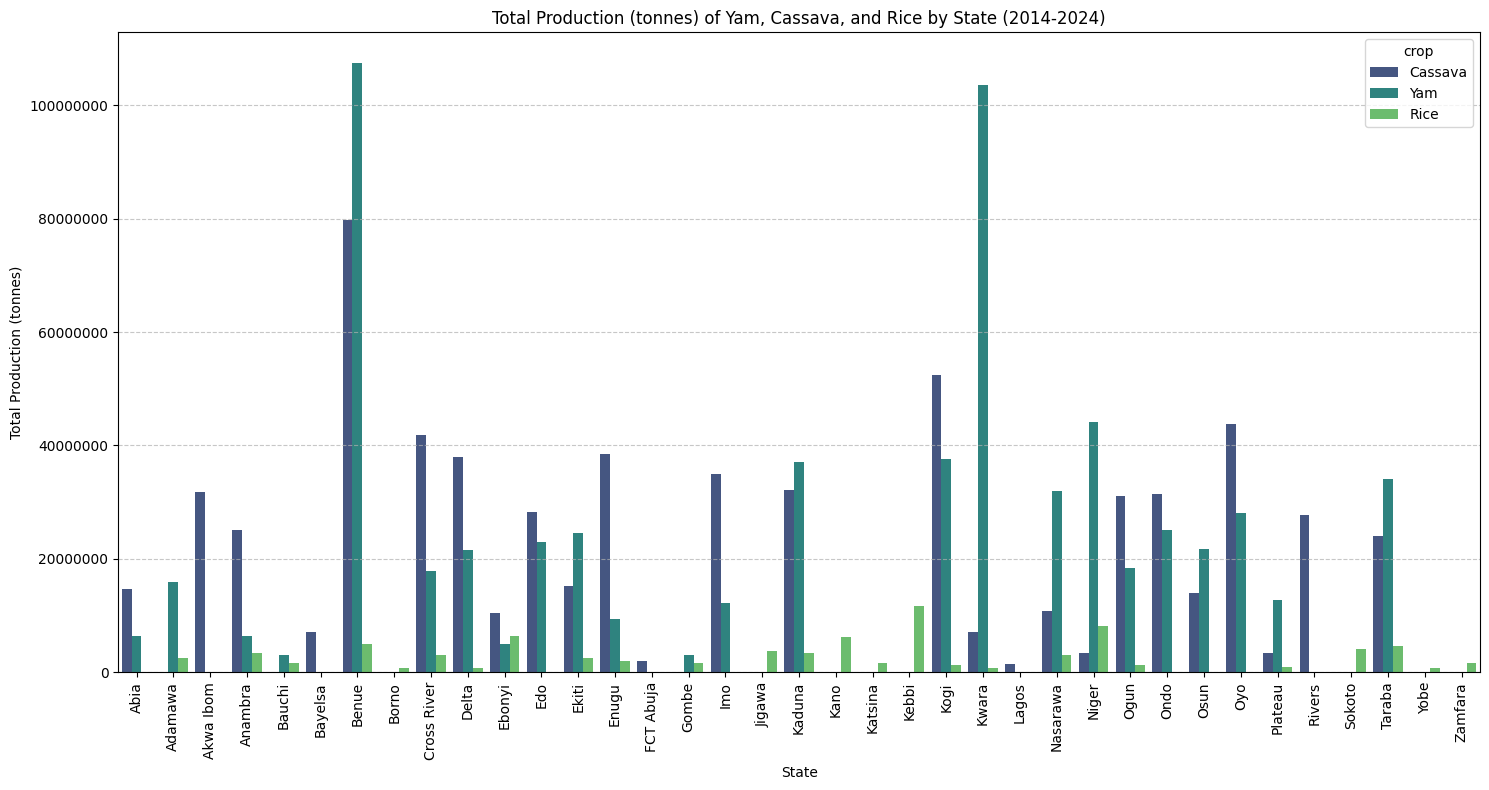

In [11]:
plt.figure(figsize=(15, 8))
sns.barplot(x='state', y='production_tonnes', hue='crop', data=selected_crops_production, palette='viridis')
plt.title('Total Production (tonnes) of Yam, Cassava, and Rice by State (2014-2024)')
plt.xlabel('State')
plt.ylabel('Total Production (tonnes)')
plt.xticks(rotation=90) # Rotate state names for better readability
plt.ticklabel_format(style='plain', axis='y') # Disable scientific notation for y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Production Trends Over Years for Yam, Cassava, and Rice

In [12]:
# Calculate total production per year for selected crops
production_by_year_crop = df_crop_output[df_crop_output['crop'].isin(['Yam', 'Cassava', 'Rice'])].groupby(['year', 'crop'])['production_tonnes'].sum().reset_index()

print('Total Production (tonnes) for Yam, Cassava, and Rice by Year:')
display(production_by_year_crop.head())


Total Production (tonnes) for Yam, Cassava, and Rice by Year:


,year,crop,production_tonnes
0,2014,Cassava,5.449264e+07
1,2014,Rice,6.548487e+06
2,2014,Yam,1.252085e+08
3,2015,Cassava,5.542404e+07
4,2015,Rice,6.789353e+06


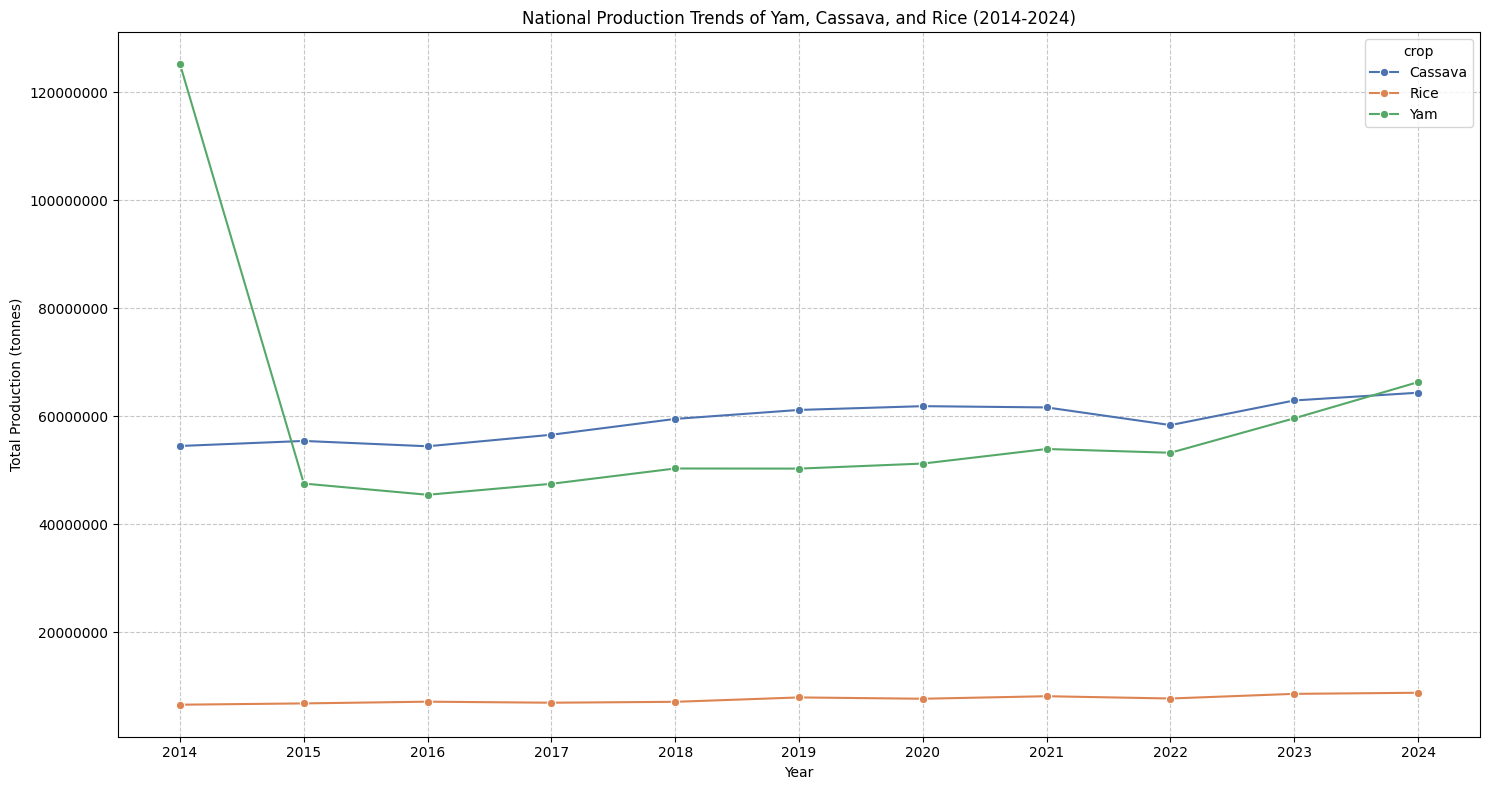

In [13]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='year', y='production_tonnes', hue='crop', data=production_by_year_crop, marker='o', palette='deep')
plt.title('National Production Trends of Yam, Cassava, and Rice (2014-2024)')
plt.xlabel('Year')
plt.ylabel('Total Production (tonnes)')
plt.xticks(production_by_year_crop['year'].unique()) # Ensure all years are shown on x-axis
plt.ticklabel_format(style='plain', axis='y') # Disable scientific notation for y-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Top Producing States for Yam, Cassava, and Rice

In [14]:
# Filter the production_by_state_crop DataFrame for the selected crops
selected_crops_production = production_by_state_crop[production_by_state_crop['crop'].isin(['Yam', 'Cassava', 'Rice'])]

# Get top states for each crop
top_states_yam = selected_crops_production[selected_crops_production['crop'] == 'Yam'].nlargest(5, 'production_tonnes')
top_states_cassava = selected_crops_production[selected_crops_production['crop'] == 'Cassava'].nlargest(5, 'production_tonnes')
top_states_rice = selected_crops_production[selected_crops_production['crop'] == 'Rice'].nlargest(5, 'production_tonnes')

print('Top 5 Yam Producing States:')
display(top_states_yam)

print('\nTop 5 Cassava Producing States:')
display(top_states_cassava)

print('\nTop 5 Rice Producing States:')
display(top_states_rice)


Top 5 Yam Producing States:


,state,crop,production_tonnes
16,Benue,Yam,1.074632e+08
67,Kwara,Yam,1.035599e+08
76,Niger,Yam,4.420555e+07
63,Kogi,Yam,3.755256e+07
53,Kaduna,Yam,3.708032e+07



Top 5 Cassava Producing States:


,state,crop,production_tonnes
13,Benue,Cassava,7.972371e+07
60,Kogi,Cassava,5.236217e+07
86,Oyo,Cassava,4.382943e+07
19,Cross River,Cassava,4.192164e+07
37,Enugu,Cassava,3.853159e+07



Top 5 Rice Producing States:


,state,crop,production_tonnes
59,Kebbi,Rice,1.167508e+07
75,Niger,Rice,8.126766e+06
28,Ebonyi,Rice,6.405077e+06
55,Kano,Rice,6.147610e+06
15,Benue,Rice,5.051892e+06


### Average Yield (tonnes/ha) for Yam, Cassava, and Rice by State

In [15]:
# Calculate average yield per state and crop for the selected crops
average_yield_by_state_crop = df_crop_output[df_crop_output['crop'].isin(['Yam', 'Cassava', 'Rice'])].groupby(['state', 'crop'])['yield_t_per_ha'].mean().reset_index()

print('Average Yield (tonnes/ha) for Yam, Cassava, and Rice by State:')
display(average_yield_by_state_crop.head())


Average Yield (tonnes/ha) for Yam, Cassava, and Rice by State:


,state,crop,yield_t_per_ha
0,Abia,Cassava,11.302727
1,Abia,Yam,13.237273
2,Adamawa,Rice,2.421818
3,Adamawa,Yam,12.051818
4,Akwa Ibom,Cassava,12.280000


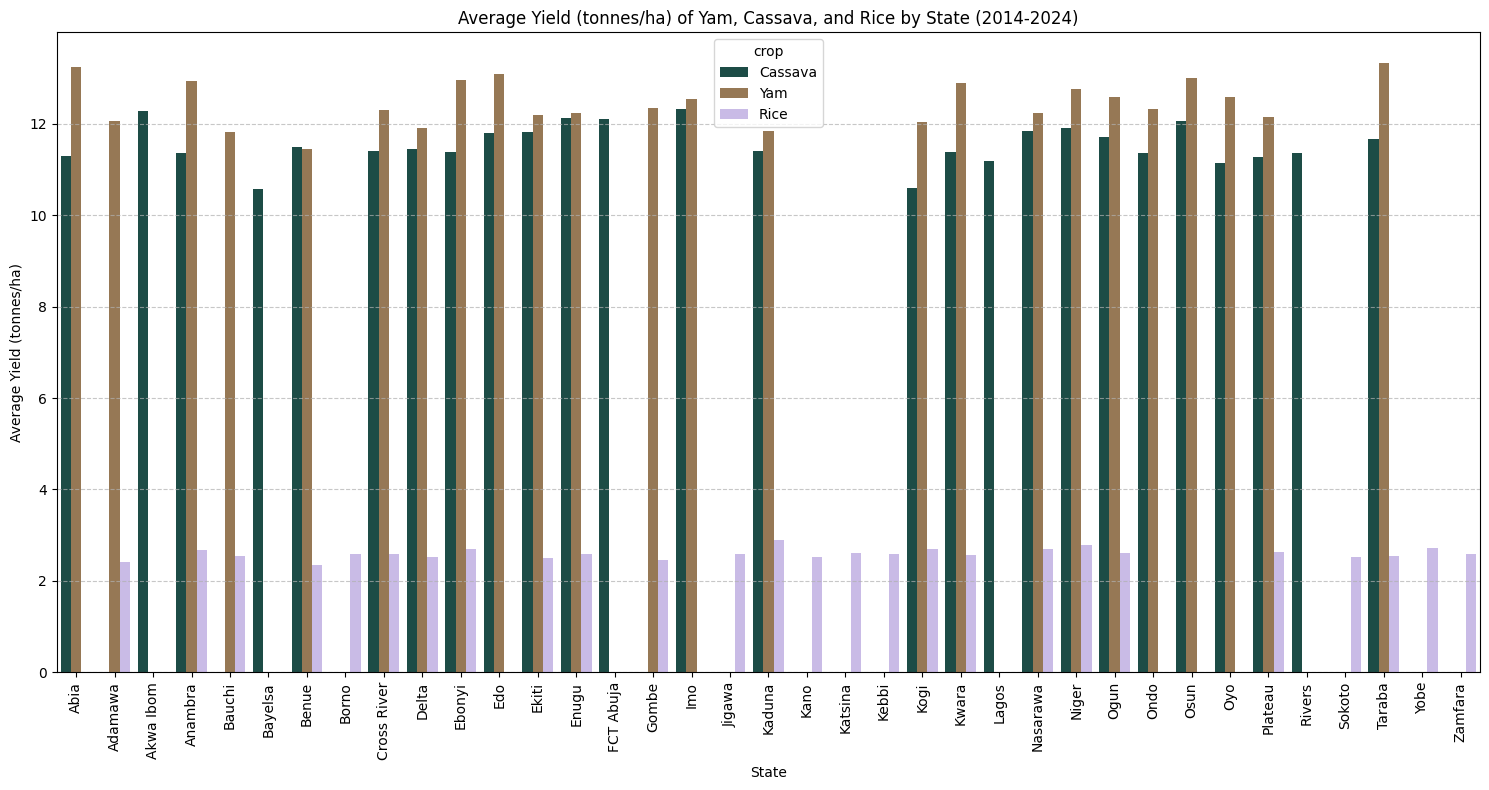

In [16]:
plt.figure(figsize=(15, 8))
sns.barplot(x='state', y='yield_t_per_ha', hue='crop', data=average_yield_by_state_crop, palette='cubehelix')
plt.title('Average Yield (tonnes/ha) of Yam, Cassava, and Rice by State (2014-2024)')
plt.xlabel('State')
plt.ylabel('Average Yield (tonnes/ha)')
plt.xticks(rotation=90) # Rotate state names for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Correlation Matrix for Key Production Metrics

In [17]:
# Select the relevant columns for correlation analysis
correlation_data = df_crop_output[['area_harvested_ha', 'yield_t_per_ha', 'production_tonnes']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

print('Correlation Matrix:')
display(correlation_matrix)


Correlation Matrix:


,area_harvested_ha,yield_t_per_ha,production_tonnes
area_harvested_ha,1.000000,0.064190,0.390037
yield_t_per_ha,0.064190,1.000000,0.323341
production_tonnes,0.390037,0.323341,1.000000


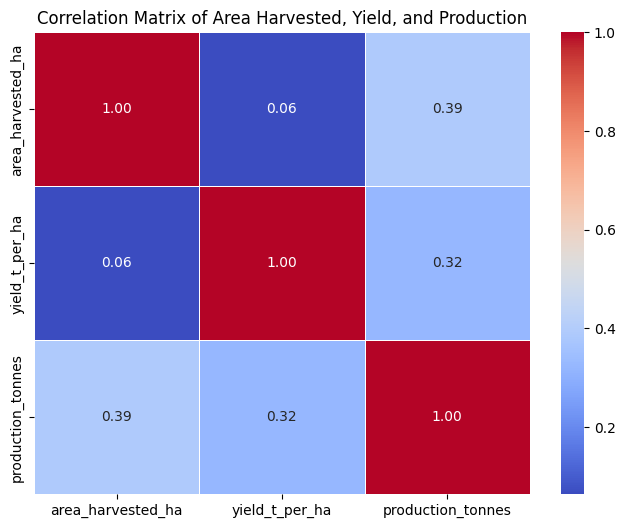

In [18]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Area Harvested, Yield, and Production')
plt.show()


### Linear Regression Model for Production Prediction

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Define features (X) and target (y)
X = df_crop_output[['area_harvested_ha', 'yield_t_per_ha']]
y = df_crop_output['production_tonnes']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)

print(f"Model Coefficients (Area Harvested, Yield): {model.coef_}")
print(f"Model Intercept: {model.intercept_}")
print(f"R-squared on Test Set: {r2:.4f}")


Model Coefficients (Area Harvested, Yield): [6.92500823e+00 1.72824474e+05]
Model Intercept: -1068713.208592159
R-squared on Test Set: 0.8010


In [20]:
from sklearn.metrics import mean_absolute_error

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error on Test Set: {mae:.4f}")

Mean Absolute Error on Test Set: 536776.7916


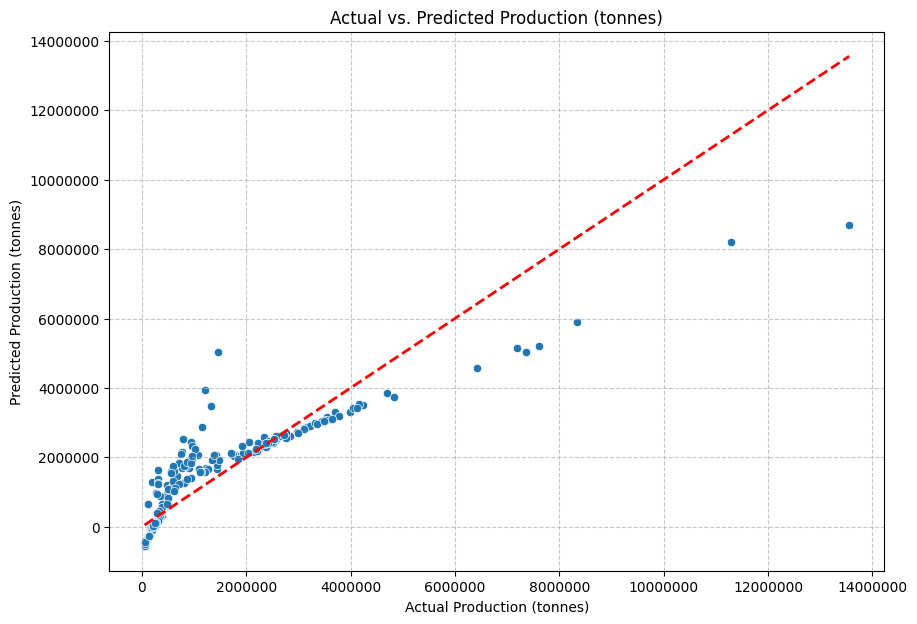

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Add a diagonal line for perfect prediction
plt.title('Actual vs. Predicted Production (tonnes)')
plt.xlabel('Actual Production (tonnes)')
plt.ylabel('Predicted Production (tonnes)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='x') # Disable scientific notation for x-axis
plt.ticklabel_format(style='plain', axis='y') # Disable scientific notation for y-axis
plt.show()

## The Indispensable Role of Data in Crop Output Planning

Our analysis of Nigerian agricultural output data for Yam, Cassava, and Rice from 2014-2024 unequivocally demonstrates the critical need for data in effective crop output planning. Through various stages of data processing and analysis, we've gained insights that are directly applicable to optimizing agricultural strategies:

1.  **Data Cleaning and Preparation:** Initially, we addressed missing production values by imputing them based on area harvested and yield. This step highlighted that even imperfect data, once carefully cleaned and prepared, can be made valuable, underscoring the importance of robust data collection and handling for any planning initiative.

2.  **Exploratory Data Analysis (EDA):**
    *   **Crop Dominance:** Identifying Cassava and Yam as the dominant crops at a national level informs resource allocation and policy focus.
    *   **Regional Variations:** Visualizing production and yield by state revealed significant regional differences. This allows planners to understand which states are high-producing or high-yielding for specific crops, enabling targeted interventions, infrastructure development, and support programs.
    *   **Production Trends:** Analyzing year-over-year trends for key crops helps in understanding growth patterns, identifying potential challenges (e.g., stagnant growth), and forecasting future output. Such trends are vital for national food security planning and market stability.
    *   **Top Producers:** Pinpointing the top-producing states for each crop helps in recognizing and supporting successful regions, potentially replicating best practices elsewhere.

3.  **Correlation Analysis:** By examining the relationships between `area_harvested_ha`, `yield_t_per_ha`, and `production_tonnes`, we found that while area and yield both correlate with production, they have a very low correlation with each other. This data-driven insight suggests that factors driving area expansion are largely independent of those driving yield efficiency, meaning strategies should be tailored for each.

4.  **Regression Modeling:**
    *   Our linear regression model to predict `production_tonnes` achieved an R-squared of approximately 0.8010, indicating it explains about 80.1% of the variance in production based on `area_harvested_ha` and `yield_t_per_ha`.
    *   Crucially, the coefficients showed that `yield_t_per_ha` has a significantly larger impact on total `production_tonnes` (coefficient ~172,824) compared to `area_harvested_ha` (coefficient ~6.93). The **Mean Absolute Error (MAE) of 536,776.7916** provides a measure of the average magnitude of errors in our predictions, giving planners an understanding of the model's reliability.
    *   The visualization of actual vs. predicted production further reinforced the model's ability to capture the underlying patterns in the data.

**Conclusion:** These findings provide clear, actionable insights for crop output planning. Instead of relying on assumptions or anecdotal evidence, data allows policymakers and agricultural stakeholders to:

*   **Prioritize Investments:** Focus on improving yield efficiency (e.g., through better seeds, irrigation, farming techniques) as it has a much higher leverage on total production than merely expanding cultivated land.
*   **Allocate Resources Strategically:** Direct resources to states with high potential or specific needs based on their current production and yield profiles.
*   **Develop Targeted Policies:** Create policies that address the distinct drivers of area expansion and yield improvement.
*   **Forecast and Prepare:** Make more accurate forecasts for future output, aiding in food security planning, market regulation, and emergency preparedness.

In essence, data transforms agricultural planning from a reactive, generalized approach to a proactive, precise, and highly effective strategy.